# F30 Brain Figure — Scherf-style ventral surface maps

**Key fix**: Project continuous zstats to surface PER CATEGORY, average across
controls, THEN threshold and do WTA. (Not: WTA in volume → project labels.)

In [16]:
import os, sys
sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}

PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}
EXCLUDE_SUBS = ['OTC108', 'control083', 'control085', 'OTC017', 'control027']

def load_subjects():
    df = _load_csv()
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        sessions = get_sessions(sub_clean)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        intact = info.get('intact_hemi', '')
        code = f"{info.get('group', '')}{sub_clean}"
        if code in EXCLUDE_SUBS:
            continue
        actual_first_ses = f'{sessions[0]:02d}'
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if sid in PRE_SURGERY_SESSIONS and ses_str in PRE_SURGERY_SESSIONS[sid]:
                continue
            post_sessions.append(ses_str)
        if not post_sessions:
            continue
        subjects[sid] = {
            'code': code, 'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

subjects = load_subjects()
print(f"Loaded {len(subjects)} subjects")

Loaded 46 subjects


In [17]:
# Cell 1: Setup
import os, sys, numpy as np, nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from nilearn import surface, datasets
from nilearn.plotting import plot_surf_roi

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}

# ── TUNE THESE ──────────────────────────────────────────────────────────
GROUP_ZTHRESH = 2.3        # raise to 3.1 if noisy, lower to 1.96 if sparse
INDIVIDUAL_ZTHRESH = 1.96  # for single patients
VOL_TO_SURF_RADIUS = 3.0   # mm; try 5.0 if patchy
# ────────────────────────────────────────────────────────────────────────

CAT_COLORS = {
    'face':   '#E74C3C',  # red
    'house':  '#2ECC71',  # green
    'object': '#3498DB',  # blue
    'word':   '#F39C12',  # orange
}

cat_cmap = ListedColormap(['#808080', '#E74C3C', '#2ECC71', '#3498DB', '#F39C12'])
cat_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cat_cmap.N)

fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage')

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# Reuse your existing load_subjects() if already in memory.
# Otherwise uncomment:
subjects = load_subjects()

ctrl_sids = sorted([sid for sid, info in subjects.items()
                     if info['patient_status'] == 'control'])
print(f'Controls: {len(ctrl_sids)}')

Controls: 21


In [18]:
# Cell 2: Helpers — project continuous zstats to surface

def get_zstat_path(sub_id, session, actual_first_ses, cope_num):
    """Path to MNI-registered category zstat."""
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    # Use the MNI-registered version
    return os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', 'zstat1_mni.nii.gz')


def project_zstats_to_surface(sub_id, session, actual_first_ses,
                               hemi_nilearn, use_mni_dir=None):
    """
    Project all 4 category zstats to fsaverage surface as CONTINUOUS values.
    
    If use_mni_dir is set, look for pre-registered MNI zstats there.
    Otherwise use the zstats from the feat directory directly.
    """
    pial = fsaverage[f'pial_{hemi_nilearn}']
    surf_z = {}

    for cat, cope_num in CAT_VS_ALL_COPES.items():
        if use_mni_dir:
            mni_path = os.path.join(use_mni_dir,
                f'{sub_id}_ses-{session}_cope{cope_num}_zstat_mni.nii.gz')
            if os.path.exists(mni_path):
                path = mni_path
            else:
                path = get_zstat_path(sub_id, session, actual_first_ses, cope_num)
        else:
            path = get_zstat_path(sub_id, session, actual_first_ses, cope_num)

        if not os.path.exists(path):
            print(f'    MISSING: {path}')
            return None

        img = nib.load(path)
        surf_z[cat] = surface.vol_to_surf(
            img, pial,
            interpolation='linear',   # LINEAR for continuous data
            radius=VOL_TO_SURF_RADIUS,
            kind='line',
        )
    return surf_z


def surface_wta(surf_zstats, threshold):
    """WTA on continuous surface zstats. Returns roi_map (0=none, 1-4=category)."""
    zmat = np.column_stack([surf_zstats[cat] for cat in CATEGORIES])
    max_z = np.max(zmat, axis=1)
    winner = np.argmax(zmat, axis=1) + 1
    return np.where(max_z >= threshold, winner, 0).astype(int)

print('Helpers defined.')

Helpers defined.


In [19]:
# Cell 3: Compute group-average control maps
# Average continuous zstats on the surface, THEN WTA.

ctrl_roi = {}

for hemi_nl in ['left', 'right']:
    print(f'\n── {hemi_nl.upper()} hemisphere ──')
    sum_z = None
    n_loaded = 0

    for sid in ctrl_sids:
        info = subjects[sid]
        first_ses = info['sessions'][0]
        actual_first = info['actual_first_ses']

        # ┌──────────────────────────────────────────────────────────┐
        # │  SET use_mni_dir TO YOUR MNI ZSTAT DIRECTORY, OR None   │
        # │  IF YOUR ZSTATS ARE ALREADY IN MNI SPACE.               │
        # └──────────────────────────────────────────────────────────┘
        sz = project_zstats_to_surface(
            sid, first_ses, actual_first, hemi_nl,
            use_mni_dir=None,
        )
        if sz is None:
            continue

        if sum_z is None:
            sum_z = {cat: sz[cat].copy() for cat in CATEGORIES}
        else:
            for cat in CATEGORIES:
                sum_z[cat] += sz[cat]
        n_loaded += 1

    if n_loaded == 0:
        print('  No controls loaded!')
        continue

    avg_z = {cat: sum_z[cat] / n_loaded for cat in CATEGORIES}
    roi = surface_wta(avg_z, GROUP_ZTHRESH)
    ctrl_roi[hemi_nl] = roi

    print(f'  {n_loaded} controls loaded, threshold={GROUP_ZTHRESH}')
    for c, cat in enumerate(CATEGORIES):
        print(f'    {cat}: {np.sum(roi == (c+1)):,} vertices')


── LEFT hemisphere ──
  21 controls loaded, threshold=2.3
    face: 131 vertices
    house: 5,858 vertices
    object: 9,310 vertices
    word: 2,836 vertices

── RIGHT hemisphere ──
  21 controls loaded, threshold=2.3
    face: 2,119 vertices
    house: 7,399 vertices
    object: 4,594 vertices
    word: 1,212 vertices


In [ ]:
# Cell 4: VOTC mask + helper functions

from collections import deque
from nilearn import datasets as nl_datasets
from nilearn.surface import load_surf_mesh

# ── VOTC mask from Harvard-Oxford (already in MNI 2mm) ───────────────────
ho_atlas = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho_atlas.maps if isinstance(ho_atlas.maps, nib.Nifti1Image) else nib.load(ho_atlas.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho_atlas.labels

votc_label_names = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

votc_mask_data = np.zeros(ho_data.shape, dtype=bool)
for name in votc_label_names:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        votc_mask_data |= (ho_data == matches[0])

votc_mask_img = nib.Nifti1Image(votc_mask_data.astype(np.float32), ho_img.affine)

# Project to surface — bilateral, each pial picks up its own hemisphere
votc_mask_surf = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_left'],
    interpolation='nearest', radius=6.0, kind='ball') > 0
votc_mask_surf_rh = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_right'],
    interpolation='nearest', radius=6.0, kind='ball') > 0

print(f'LH VOTC mask: {votc_mask_surf.sum():,} vertices')
print(f'RH VOTC mask: {votc_mask_surf_rh.sum():,} vertices')

# ── Store avg_z for both hemispheres (from Cell 3) ───────────────────────
# Cell 3 only stored ctrl_roi but we need continuous avg_z for layering.
# Recompute avg_z_lh and avg_z_rh:
avg_z_store = {}
for hemi_nl in ['left', 'right']:
    sum_z = None
    n_loaded = 0
    for sid in ctrl_sids:
        info = subjects[sid]
        first_ses = info['sessions'][0]
        actual_first = info['actual_first_ses']
        sz = project_zstats_to_surface(sid, first_ses, actual_first, hemi_nl, use_mni_dir=None)
        if sz is None:
            continue
        if sum_z is None:
            sum_z = {cat: sz[cat].copy() for cat in CATEGORIES}
        else:
            for cat in CATEGORIES:
                sum_z[cat] += sz[cat]
        n_loaded += 1
    avg_z_store[hemi_nl] = {cat: sum_z[cat] / n_loaded for cat in CATEGORIES}
    print(f'{hemi_nl}: {n_loaded} controls averaged')

avg_z_lh = avg_z_store['left']
avg_z_rh = avg_z_store['right']

# ── Helper: layered ROI (word painted last) ──────────────────────────────
LAYER_ORDER = ['object', 'house', 'face', 'word']  # word LAST = on top
cat_idx_map = {cat: c + 1 for c, cat in enumerate(CATEGORIES)}

def layered_roi(surf_zstats, threshold, votc_mask,
                word_threshold=None, face_threshold=None):
    """Paint categories in order — later ones overwrite earlier ones."""
    n_verts = len(votc_mask)
    roi = np.zeros(n_verts, dtype=int)
    for cat in LAYER_ORDER:
        if cat == 'word' and word_threshold is not None:
            t = word_threshold
        elif cat == 'face' and face_threshold is not None:
            t = face_threshold
        else:
            t = threshold
        above = (surf_zstats[cat] > t) & votc_mask
        roi[above] = cat_idx_map[cat]
    return roi

# ── Helper: remove small clusters ────────────────────────────────────────
def remove_small_clusters(roi_map, faces, min_size=30):
    n_verts = len(roi_map)
    adj = [set() for _ in range(n_verts)]
    for f in faces:
        adj[f[0]].update([f[1], f[2]])
        adj[f[1]].update([f[0], f[2]])
        adj[f[2]].update([f[0], f[1]])
    cleaned = roi_map.copy()
    visited = np.zeros(n_verts, dtype=bool)
    for v in range(n_verts):
        if visited[v] or roi_map[v] == 0:
            continue
        cat_val = roi_map[v]
        cluster = []
        queue = deque([v])
        visited[v] = True
        while queue:
            curr = queue.popleft()
            cluster.append(curr)
            for nb in adj[curr]:
                if not visited[nb] and roi_map[nb] == cat_val:
                    visited[nb] = True
                    queue.append(nb)
        if len(cluster) < min_size:
            for idx in cluster:
                cleaned[idx] = 0
    return cleaned

# ── Mesh faces for cluster cleaning ──────────────────────────────────────
coords, faces_mesh = load_surf_mesh(fsaverage['infl_left'])

# ── Colormaps ────────────────────────────────────────────────────────────
cat_cmap_bright = ListedColormap([
    '#808080', '#E74C3C', '#2ECC71', '#3498DB', '#FFD700'])
CAT_COLORS_BRIGHT = {
    'face': '#E74C3C', 'house': '#2ECC71',
    'object': '#3498DB', 'word': '#FFD700'}

print('\nCell 4 done: VOTC masks, helpers, colormaps ready.')

LH VOTC mask: 36,129 vertices
RH VOTC mask: 34,876 vertices
left: 21 controls averaged
right: 21 controls averaged

Cell 4 done: VOTC masks, helpers, colormaps ready.


In [54]:
# Cell 4: VOTC mask + helper functions

from collections import deque
from nilearn import datasets as nl_datasets
from nilearn.surface import load_surf_mesh

# ── VOTC mask from Harvard-Oxford (already in MNI 2mm) ───────────────────
ho_atlas = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho_atlas.maps if isinstance(ho_atlas.maps, nib.Nifti1Image) else nib.load(ho_atlas.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho_atlas.labels

votc_label_names = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

votc_mask_data = np.zeros(ho_data.shape, dtype=bool)
for name in votc_label_names:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        votc_mask_data |= (ho_data == matches[0])

votc_mask_img = nib.Nifti1Image(votc_mask_data.astype(np.float32), ho_img.affine)

votc_mask_surf = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_left'],
    interpolation='nearest', radius=6.0, kind='ball') > 0
votc_mask_surf_rh = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_right'],
    interpolation='nearest', radius=6.0, kind='ball') > 0

print(f'LH VOTC mask: {votc_mask_surf.sum():,} vertices')
print(f'RH VOTC mask: {votc_mask_surf_rh.sum():,} vertices')

# ── Recompute avg_z for both hemispheres (need continuous values for layering)
avg_z_lh_sum, avg_z_rh_sum = None, None
n_ctrl_lh, n_ctrl_rh = 0, 0

for sid in ctrl_sids:
    info = subjects[sid]
    first_ses = info['sessions'][0]
    actual_first = info['actual_first_ses']
    for hemi_nl, label in [('left', 'lh'), ('right', 'rh')]:
        sz = project_zstats_to_surface(sid, first_ses, actual_first, hemi_nl, use_mni_dir=None)
        if sz is None:
            continue
        if hemi_nl == 'left':
            if avg_z_lh_sum is None:
                avg_z_lh_sum = {cat: sz[cat].copy() for cat in CATEGORIES}
            else:
                for cat in CATEGORIES:
                    avg_z_lh_sum[cat] += sz[cat]
            n_ctrl_lh += 1
        else:
            if avg_z_rh_sum is None:
                avg_z_rh_sum = {cat: sz[cat].copy() for cat in CATEGORIES}
            else:
                for cat in CATEGORIES:
                    avg_z_rh_sum[cat] += sz[cat]
            n_ctrl_rh += 1

avg_z_lh = {cat: avg_z_lh_sum[cat] / n_ctrl_lh for cat in CATEGORIES}
avg_z_rh = {cat: avg_z_rh_sum[cat] / n_ctrl_rh for cat in CATEGORIES}
print(f'LH: {n_ctrl_lh} controls, RH: {n_ctrl_rh} controls')

# ── Layered ROI: word painted LAST (always on top) ───────────────────────
LAYER_ORDER = ['object', 'house', 'face', 'word']
cat_idx_map = {cat: c + 1 for c, cat in enumerate(CATEGORIES)}

def layered_roi(surf_zstats, threshold, votc_mask,
                word_threshold=None, face_threshold=None):
    n_verts = len(votc_mask)
    roi = np.zeros(n_verts, dtype=int)
    for cat in LAYER_ORDER:
        if cat == 'word' and word_threshold is not None:
            t = word_threshold
        elif cat == 'face' and face_threshold is not None:
            t = face_threshold
        else:
            t = threshold
        above = (surf_zstats[cat] > t) & votc_mask
        roi[above] = cat_idx_map[cat]
    return roi

# ── Cluster cleaning ─────────────────────────────────────────────────────
def remove_small_clusters(roi_map, mesh_faces, min_size=30):
    n_verts = len(roi_map)
    adj = [set() for _ in range(n_verts)]
    for f in mesh_faces:
        adj[f[0]].update([f[1], f[2]])
        adj[f[1]].update([f[0], f[2]])
        adj[f[2]].update([f[0], f[1]])
    cleaned = roi_map.copy()
    visited = np.zeros(n_verts, dtype=bool)
    for v in range(n_verts):
        if visited[v] or roi_map[v] == 0:
            continue
        cat_val = roi_map[v]
        cluster = []
        queue = deque([v])
        visited[v] = True
        while queue:
            curr = queue.popleft()
            cluster.append(curr)
            for nb in adj[curr]:
                if not visited[nb] and roi_map[nb] == cat_val:
                    visited[nb] = True
                    queue.append(nb)
        if len(cluster) < min_size:
            for idx in cluster:
                cleaned[idx] = 0
    return cleaned

coords, faces_mesh = load_surf_mesh(fsaverage['infl_left'])

# ── Colormaps ────────────────────────────────────────────────────────────
cat_cmap_bright = ListedColormap([
    '#808080', '#E74C3C', '#2ECC71', '#3498DB', '#FFD700'])
CAT_COLORS_BRIGHT = {
    'face': '#E74C3C', 'house': '#2ECC71',
    'object': '#3498DB', 'word': '#FFD700'}

print('Cell 4 done.')

LH VOTC mask: 36,129 vertices
RH VOTC mask: 34,876 vertices
LH: 21 controls, RH: 21 controls
Cell 4 done.


Controls LH (layered, z>2.3):
  face: 196
  house: 5,519
  object: 7,184
  word: 713

Controls RH (layered, z>2.3):
  face: 1,995
  house: 6,790
  object: 3,392
  word: 452

sub-008 (LAYERED, face z>5.0, word z>1.5, rest z>2.3):
  face: 2,936
  house: 5,466
  object: 1,601
  word: 1,591


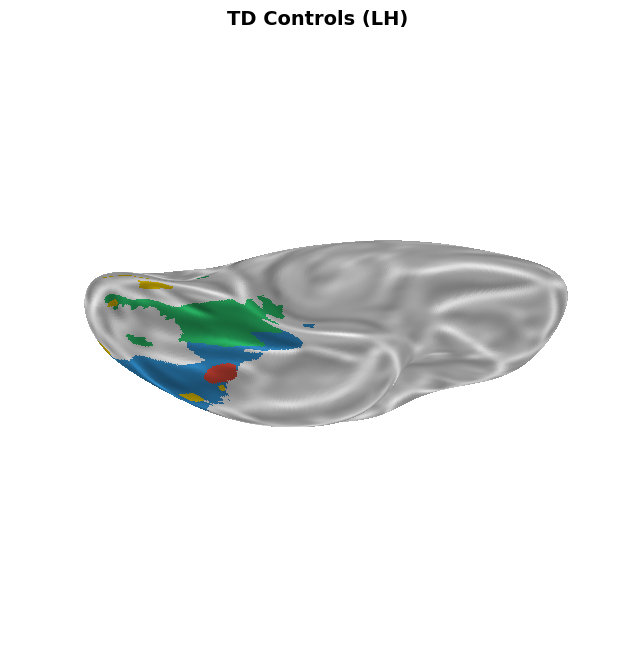

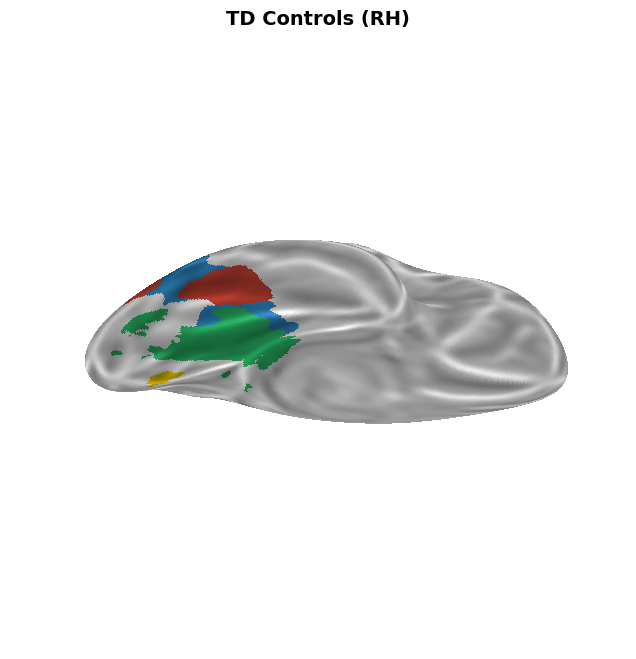

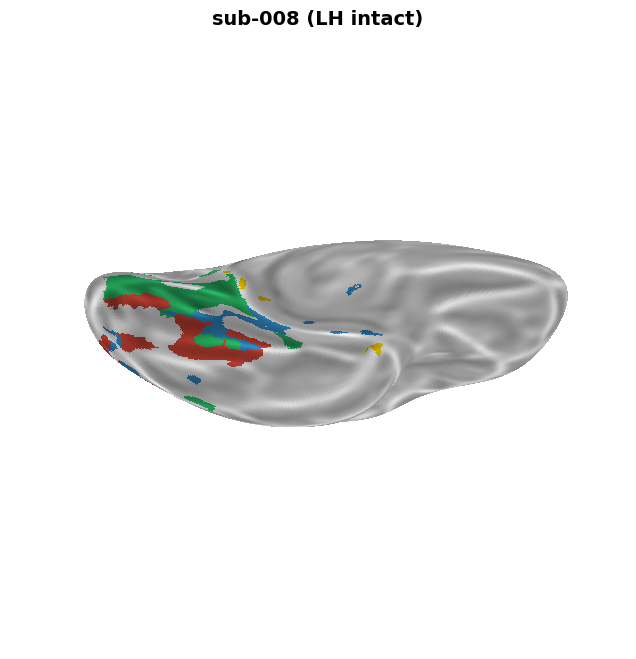

In [57]:
# Cell 5: Compute control + patient layered ROIs [new ]

# ── Controls: layered, uniform threshold, VOTC masked ────────────────────
CTRL_THRESH = GROUP_ZTHRESH  # 2.3

ctrl_layer_lh = layered_roi(avg_z_lh, CTRL_THRESH, votc_mask_surf)
ctrl_layer_rh = layered_roi(avg_z_rh, CTRL_THRESH, votc_mask_surf_rh)

print(f'Controls LH (layered, z>{CTRL_THRESH}):')
for c, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {np.sum(ctrl_layer_lh == (c+1)):,}')

print(f'\nControls RH (layered, z>{CTRL_THRESH}):')
for c, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {np.sum(ctrl_layer_rh == (c+1)):,}')

# ── Patient: layered, face strict, word lenient ──────────────────────────
patient_sid = 'sub-008'
info = subjects[patient_sid]
first_ses = info['sessions'][0]
actual_first = info['actual_first_ses']

surf_z_008 = project_zstats_to_surface(
    patient_sid, first_ses, actual_first, 'left', use_mni_dir=None)

PAT_THRESH = 2.3
PAT_FACE_THRESH = 5.0     # curb face spread
PAT_WORD_THRESH = 1.5     # ensure word visibility

pat_layer = layered_roi(surf_z_008, PAT_THRESH, votc_mask_surf,
                        word_threshold=PAT_WORD_THRESH,
                        face_threshold=PAT_FACE_THRESH)
pat_layer = remove_small_clusters(pat_layer, faces_mesh, min_size=30)

print(f'\nsub-008 (LAYERED, face z>{PAT_FACE_THRESH}, word z>{PAT_WORD_THRESH}, rest z>{PAT_THRESH}):')
for c, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {np.sum(pat_layer == (c+1)):,}')
    
# ── Standalone plots for each panel ──────────────────────────────────────

# Control LH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(
    fsaverage['infl_left'], roi_map=ctrl_layer_lh,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_left'],
    bg_on_data=True, darkness=0.7, axes=ax)
ax.set_title('TD Controls (LH)', fontsize=14, fontweight='bold')
plt.show()

# Control RH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(
    fsaverage['infl_right'], roi_map=ctrl_layer_rh,
    hemi='right', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_right'],
    bg_on_data=True, darkness=0.7, axes=ax)
ax.set_title('TD Controls (RH)', fontsize=14, fontweight='bold')
plt.show()

# Patient LH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(
    fsaverage['infl_left'], roi_map=pat_layer,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_left'],
    bg_on_data=True, darkness=0.7, axes=ax)
ax.set_title('sub-008 (LH intact)', fontsize=14, fontweight='bold')
plt.show()

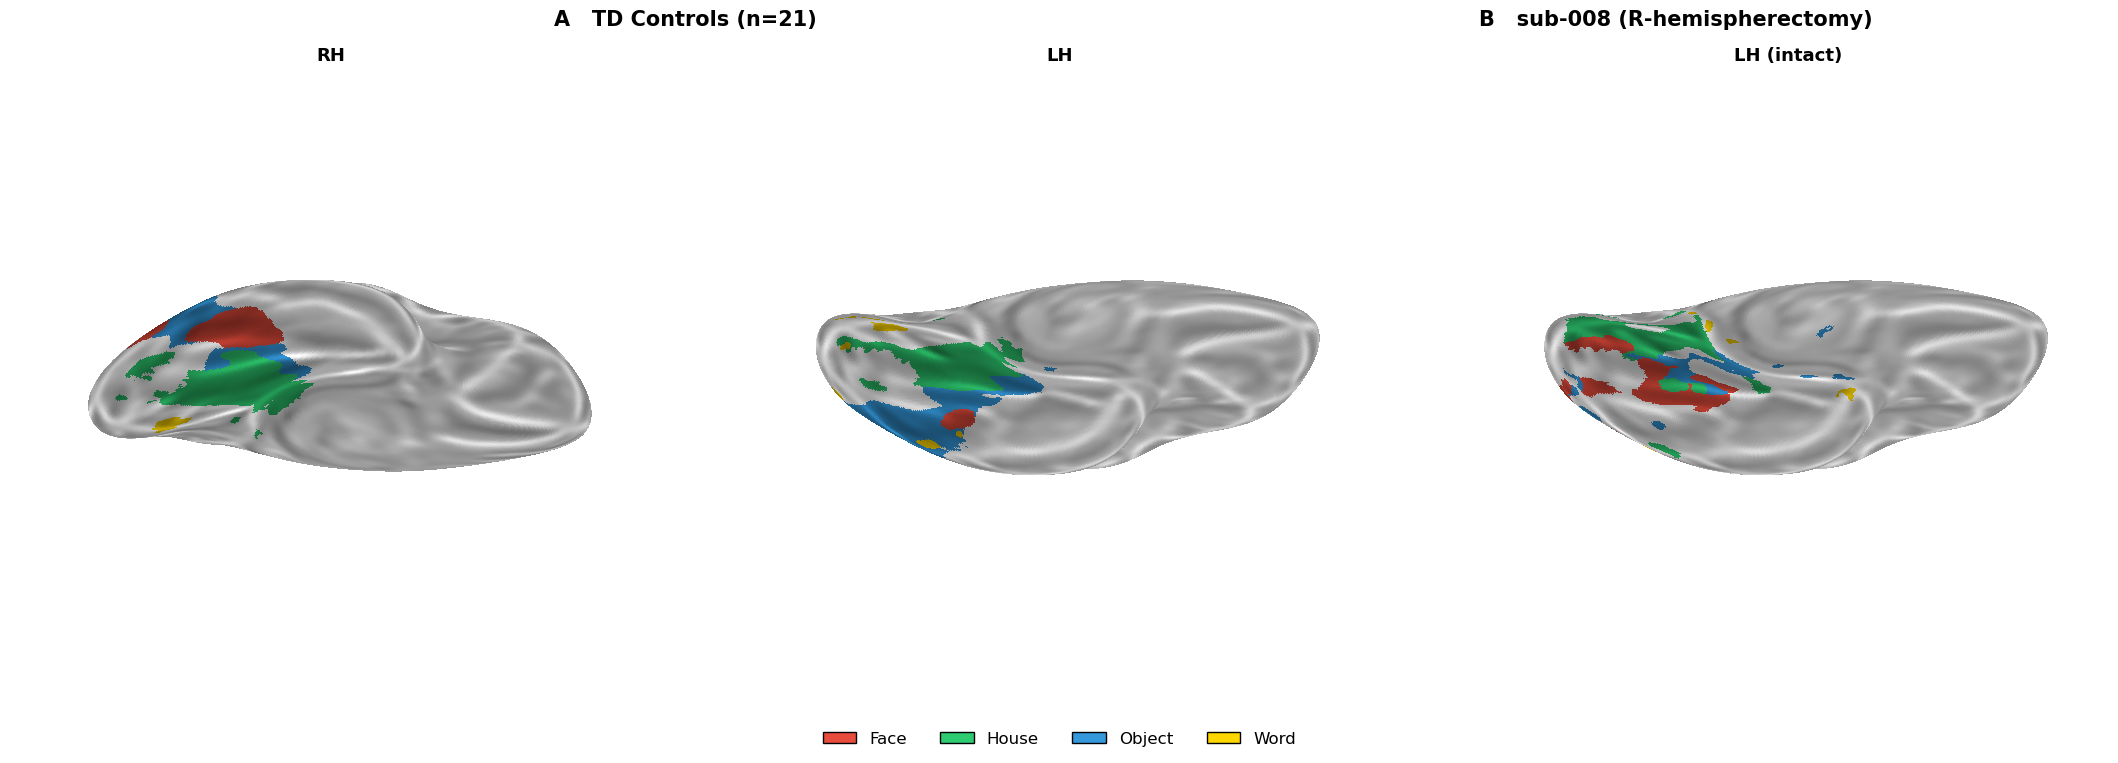

In [56]:
# Cell 6: Composite F30 figure [new

fig = plt.figure(figsize=(22, 8))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
plot_surf_roi(
    fsaverage['infl_right'], roi_map=ctrl_layer_rh,
    hemi='right', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_right'],
    bg_on_data=True, darkness=0.7, axes=ax1)
ax1.set_title('RH', fontsize=13, fontweight='bold', pad=-10)

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
plot_surf_roi(
    fsaverage['infl_left'], roi_map=ctrl_layer_lh,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_left'],
    bg_on_data=True, darkness=0.7, axes=ax2)
ax2.set_title('LH', fontsize=13, fontweight='bold', pad=-10)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
plot_surf_roi(
    fsaverage['infl_left'], roi_map=pat_layer,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['curv_left'],
    bg_on_data=True, darkness=0.7, axes=ax3)
ax3.set_title('LH (intact)', fontsize=13, fontweight='bold', pad=-10)

fig.text(0.33, 0.93, f'A   TD Controls (n={n_ctrl_lh})',
         fontsize=15, fontweight='bold', ha='center')
fig.text(0.78, 0.93, 'B   sub-008 (R-hemispherectomy)',
         fontsize=15, fontweight='bold', ha='center')

legend_patches = [Patch(facecolor=CAT_COLORS_BRIGHT[c], edgecolor='k', label=c.capitalize())
                  for c in CATEGORIES]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()

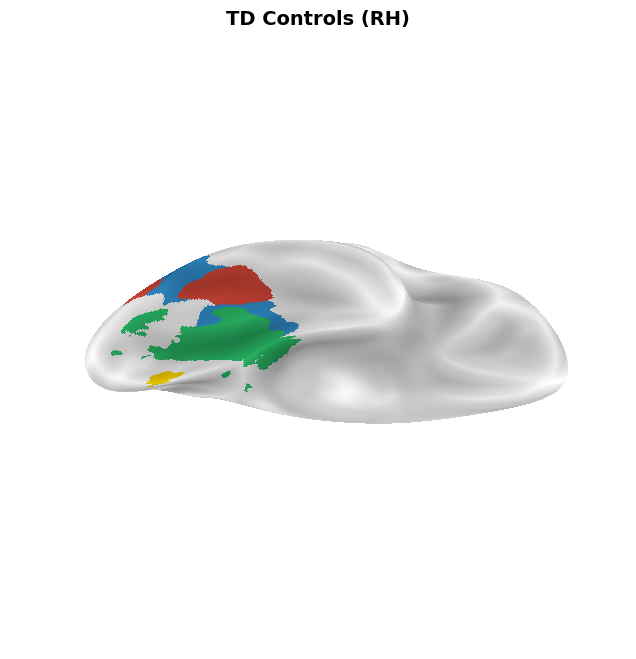

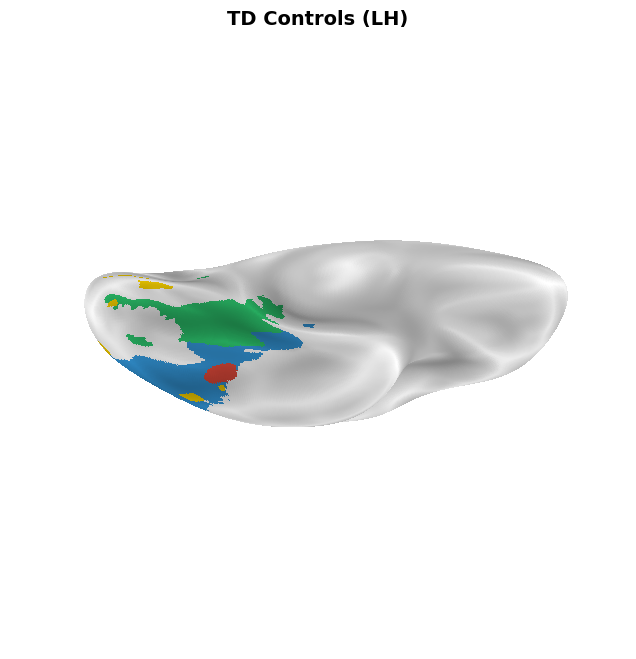

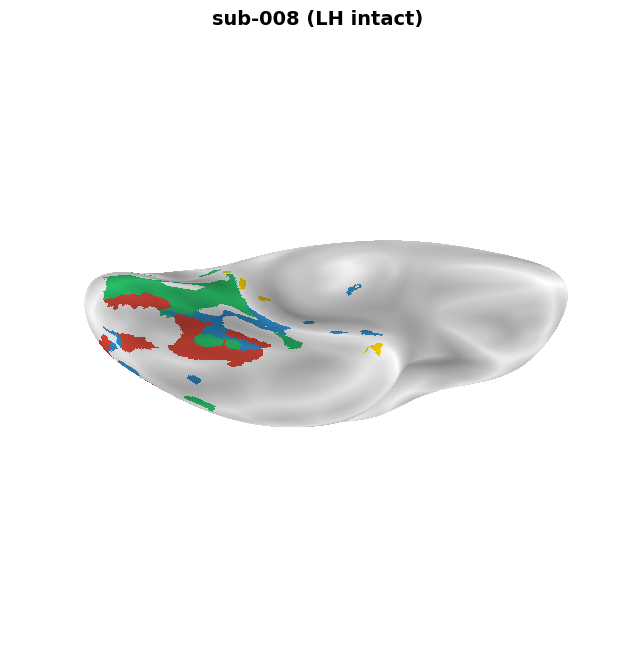

In [59]:
# Cell 6: Composite F30 figure (control + patient side by side)
# Run once you're happy with the individual panels above.

# Standalone plots — sulc background, darkness=0.5

# Control RH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(fsaverage['infl_right'], roi_map=ctrl_layer_rh,
    hemi='right', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_right'],
    bg_on_data=True, darkness=0.5, axes=ax)
ax.set_title('TD Controls (RH)', fontsize=14, fontweight='bold')
plt.show()

# Control LH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(fsaverage['infl_left'], roi_map=ctrl_layer_lh,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True, darkness=0.5, axes=ax)
ax.set_title('TD Controls (LH)', fontsize=14, fontweight='bold')
plt.show()

# sub-008 LH
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
plot_surf_roi(fsaverage['infl_left'], roi_map=pat_layer,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True, darkness=0.5, axes=ax)
ax.set_title('sub-008 (LH intact)', fontsize=14, fontweight='bold')
plt.show()

In [61]:
# Cell 7: Save final version (uncomment when happy)

out_dir = '/user_data/csimmon2/sym_pt/group_results/figures/f30_brain_figure'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'f30_composite_ctrl_vs_sub004.png'),
    dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'f30_composite_ctrl_vs_sub004.pdf'),
    bbox_inches='tight', facecolor='white')
print(f'Saved to {out_dir}')

Saved to /user_data/csimmon2/sym_pt/group_results/figures/f30_brain_figure


RH VOTC mask: 34,876 / 163,842 vertices

TD Controls LH (z>2.3):
  face: 131
  house: 4,505
  object: 8,413
  word: 563

TD Controls RH (z>2.3):
  face: 1,671
  house: 6,058
  object: 4,448
  word: 452

sub-008 LH (per-category thresh, min_cluster=30):
  face (z>4.0): 4,118
  house (z>2.5): 3,962
  object (z>2.3): 1,941
  word (z>1.8): 622


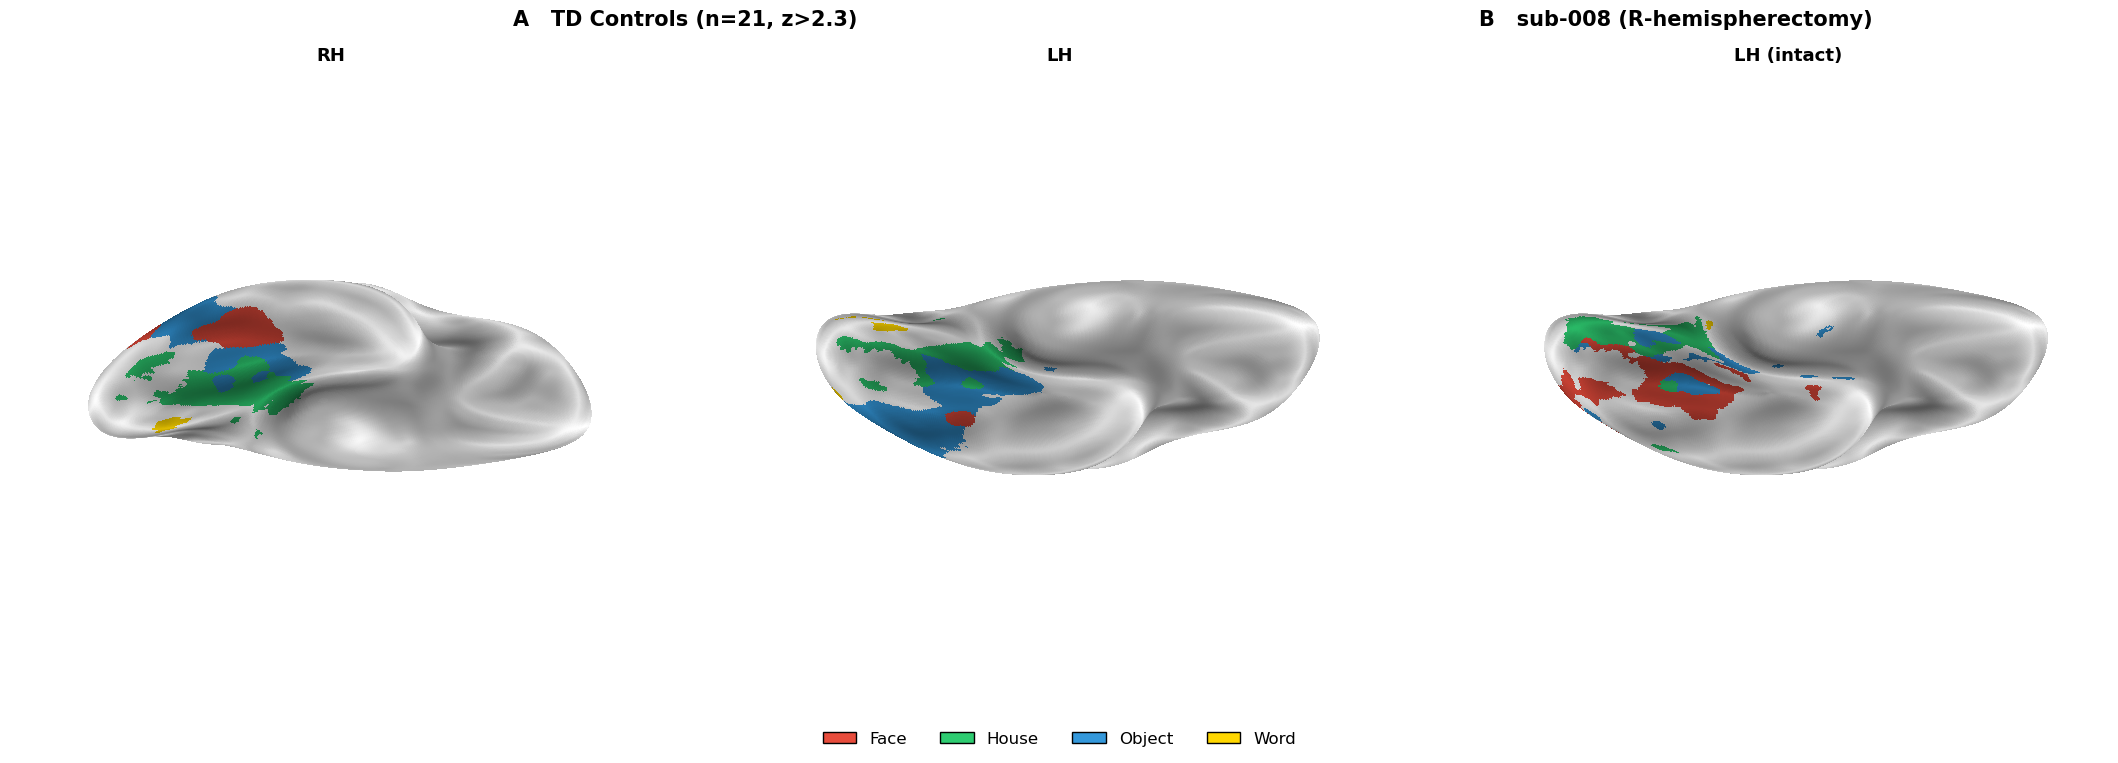

In [ ]:
# Full cell: Controls (LH + RH, uniform thresh) + sub-008 (LH, per-category thresh)

from collections import deque
from nilearn.surface import load_surf_mesh

# ── Helper functions ─────────────────────────────────────────────────────────

def apply_percat_wta(surf_zstats, thresholds, votc_mask):
    """WTA where each category must pass its own z-threshold."""
    zmat = np.column_stack([surf_zstats[cat] for cat in CATEGORIES])
    winner = np.argmax(zmat, axis=1)
    roi = np.zeros(len(winner), dtype=int)
    for v in range(len(winner)):
        cat_idx = winner[v]
        if zmat[v, cat_idx] >= thresholds[CATEGORIES[cat_idx]]:
            roi[v] = cat_idx + 1
    roi[~votc_mask] = 0
    return roi


def remove_small_clusters(roi_map, faces, min_size=30):
    """Remove surface clusters smaller than min_size using mesh adjacency."""
    n_verts = len(roi_map)
    adj = [set() for _ in range(n_verts)]
    for f in faces:
        adj[f[0]].update([f[1], f[2]])
        adj[f[1]].update([f[0], f[2]])
        adj[f[2]].update([f[0], f[1]])

    cleaned = roi_map.copy()
    visited = np.zeros(n_verts, dtype=bool)

    for v in range(n_verts):
        if visited[v] or roi_map[v] == 0:
            continue
        cat_val = roi_map[v]
        cluster = []
        queue = deque([v])
        visited[v] = True
        while queue:
            curr = queue.popleft()
            cluster.append(curr)
            for nb in adj[curr]:
                if not visited[nb] and roi_map[nb] == cat_val:
                    visited[nb] = True
                    queue.append(nb)
        if len(cluster) < min_size:
            for idx in cluster:
                cleaned[idx] = 0
    return cleaned


# ── Colormaps ────────────────────────────────────────────────────────────────
cat_cmap_bright = ListedColormap([
    '#808080',   # 0 = background
    '#E74C3C',   # 1 = face (red)
    '#2ECC71',   # 2 = house (green)
    '#3498DB',   # 3 = object (blue)
    '#FFD700',   # 4 = word (bright yellow)
])

CAT_COLORS_BRIGHT = {
    'face': '#E74C3C', 'house': '#2ECC71',
    'object': '#3498DB', 'word': '#FFD700',
}

# ── Build VOTC mask for RH too ───────────────────────────────────────────────
# (LH mask already exists as votc_mask_surf)
votc_mask_img_bilat = nib.Nifti1Image(votc_mask_data.astype(np.float32), ho_img.affine)

pial_rh = fsaverage['pial_right']
votc_surf_rh = surface.vol_to_surf(
    votc_mask_img_bilat, pial_rh,
    interpolation='nearest', radius=6.0, kind='ball',
)
votc_mask_surf_rh = votc_surf_rh > 0
print(f"RH VOTC mask: {votc_mask_surf_rh.sum():,} / {len(votc_mask_surf_rh):,} vertices")

# ── Controls: uniform threshold + VOTC mask, both hemispheres ────────────────
ctrl_roi_lh = ctrl_roi['left'].copy()
ctrl_roi_lh[~votc_mask_surf] = 0

ctrl_roi_rh = ctrl_roi['right'].copy()
ctrl_roi_rh[~votc_mask_surf_rh] = 0

print(f"\nTD Controls LH (z>{GROUP_ZTHRESH}):")
for c, cat in enumerate(CATEGORIES):
    print(f"  {cat}: {np.sum(ctrl_roi_lh == (c+1)):,}")

print(f"\nTD Controls RH (z>{GROUP_ZTHRESH}):")
for c, cat in enumerate(CATEGORIES):
    print(f"  {cat}: {np.sum(ctrl_roi_rh == (c+1)):,}")

# ── Patient: per-category thresholds + cluster cleaning (LH only) ────────────
patient_sid = 'sub-008'
info = subjects[patient_sid]
first_ses = info['sessions'][0]
actual_first = info['actual_first_ses']

surf_z_008 = project_zstats_to_surface(
    patient_sid, first_ses, actual_first, 'left', use_mni_dir=None,
)

PAT_ZTHRESH = {
    'face':   4.0,
    'house':  2.5,
    'object': 2.3,
    'word':   1.8,
}

coords, faces = load_surf_mesh(fsaverage['infl_left'])

patient_roi_v2 = apply_percat_wta(surf_z_008, PAT_ZTHRESH, votc_mask_surf)
patient_roi_v2 = remove_small_clusters(patient_roi_v2, faces, min_size=30)

print(f"\nsub-008 LH (per-category thresh, min_cluster=30):")
for c, cat in enumerate(CATEGORIES):
    print(f"  {cat} (z>{PAT_ZTHRESH[cat]}): {np.sum(patient_roi_v2 == (c+1)):,}")

# ── Plot: 3 panels [Ctrl RH | Ctrl LH | Patient LH] ────────────────────────
fig = plt.figure(figsize=(22, 8))

# Panel A: Control RH
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
plot_surf_roi(
    fsaverage['infl_right'], roi_map=ctrl_roi_rh,
    hemi='right', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_right'],
    bg_on_data=True, darkness=0.7, axes=ax1,
)
ax1.set_title('RH', fontsize=13, fontweight='bold', pad=-10)

# Panel A: Control LH
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
plot_surf_roi(
    fsaverage['infl_left'], roi_map=ctrl_roi_lh,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True, darkness=0.7, axes=ax2,
)
ax2.set_title('LH', fontsize=13, fontweight='bold', pad=-10)

# Panel B: Patient LH
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
plot_surf_roi(
    fsaverage['infl_left'], roi_map=patient_roi_v2,
    hemi='left', view='ventral',
    cmap=cat_cmap_bright, vmin=0, vmax=4,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True, darkness=0.7, axes=ax3,
)
ax3.set_title('LH (intact)', fontsize=13, fontweight='bold', pad=-10)

# Panel labels
fig.text(0.33, 0.93, f'A   TD Controls (n={len(ctrl_sids)}, z>{GROUP_ZTHRESH})',
         fontsize=15, fontweight='bold', ha='center')
fig.text(0.78, 0.93, 'B   sub-008 (R-hemispherectomy)',
         fontsize=15, fontweight='bold', ha='center')

# Legend
legend_patches = [Patch(facecolor=CAT_COLORS_BRIGHT[c], edgecolor='k', label=c.capitalize())
                  for c in CATEGORIES]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()

In [ ]:
# Standalone plots — transparent background for compositing

out_dir = '/user_data/csimmon2/sym_pt/group_results/figures/f30_brain_figure'
os.makedirs(out_dir, exist_ok=True)

for roi_map, hemi, mesh_key, sulc_key, fname, title in [
    (ctrl_layer_rh, 'right', 'infl_right', 'sulc_right', 'ctrl_RH.png', 'TD Controls (RH)'),
    (ctrl_layer_lh, 'left',  'infl_left',  'sulc_left',  'ctrl_LH.png', 'TD Controls (LH)'),
    (pat_layer,     'left',  'infl_left',  'sulc_left',  'sub008_LH.png', 'sub-008 (LH intact)'),
]:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
    plot_surf_roi(fsaverage[mesh_key], roi_map=roi_map,
        hemi=hemi, view='ventral',
        cmap=cat_cmap_bright, vmin=0, vmax=4,
        bg_map=fsaverage[sulc_key],
        bg_on_data=True, darkness=0.5, axes=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    out_path = os.path.join(out_dir, fname)
    fig.savefig(out_path, dpi=300, bbox_inches='tight', transparent=True)
    print(f'Saved: {out_path}')
    plt.show()
    plt.close(fig)